In [ ]:
# --- 1. SETUP & AUTH ---
from google.cloud import bigquery
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Project Configuration
PROJECT_ID = "mapping-nba-fouls"
DATASET_ID = "capstone_project"
BUCKET_NAME = f"{PROJECT_ID}-artifacts"

# --- 2. VERIFY MODEL ARTIFACT (Modern CLI) ---
print("Checking model artifacts in Oregon...")
!gcloud storage ls gs://{BUCKET_NAME}/whistle_net_v3_8.keras

# --- 3. FETCH DATA FROM BIGQUERY ---
client = bigquery.Client(project=PROJECT_ID)

# We group by player and season to prepare for the YoY lag calculation
query = f"""
    SELECT
        player_id,
        player_name,
        season_year,
        SUM(actual_fouls) as total_actual,
        SUM(pred_fouls) as total_pred,
        SUM(foul_delta) as total_delta
    FROM `{PROJECT_ID}.{DATASET_ID}.foul_stability_results`
    GROUP BY 1, 2, 3
    ORDER BY season_year ASC
"""

df_analysis = client.query(query).to_dataframe()
print(f"✅ Loaded {len(df_analysis)} player-season records.")

Checking model artifacts in Oregon...
gs://mapping-nba-fouls-artifacts/whistle_net_v3_8.keras
✅ Loaded 2169 player-season records.


In [ ]:
# --- RUN THIS IN THE ANALYSIS NOTEBOOK ---
dataset_ref = client.dataset(DATASET_ID, project=PROJECT_ID)
tables = list(client.list_tables(dataset_ref))

print(f"Tables found in {DATASET_ID}:")
for table in tables:
    print(f" - {table.table_id}")

Tables found in capstone_project:
 - consolidated_training_table
 - dim_games
 - dim_player_seasons
 - dim_teams
 - enriched_foul_data_v1
 - fct_fouls
 - fct_shots
 - foul_predictions_output
 - foul_stability_results
 - raw_shufinskiy_datanba
 - temp_position_mapping


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from google.cloud import bigquery
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
PROJECT_ID = "mapping-nba-fouls"
DATASET_ID = "capstone_project"
BUCKET_NAME = f"{PROJECT_ID}-artifacts"

client = bigquery.Client(project=PROJECT_ID)

# 1. Pull Shot-Level Data (1.2M rows)
print("Fetching shot-level data...")
df_filtered = client.query(f"SELECT * FROM `{PROJECT_ID}.{DATASET_ID}.enriched_foul_data_v1`").to_dataframe()

# 2. Pull Stability Results (Needed for the Player Delta signature)
print("Fetching stability summaries...")
df_analysis = client.query(f"SELECT * FROM `{PROJECT_ID}.{DATASET_ID}.foul_stability_results`").to_dataframe()

# 3. Load Model from Oregon
print("Loading WhistleNet v3.8...")
foul_model = tf.keras.models.load_model(f"gs://{BUCKET_NAME}/whistle_net_v3_8.keras")

# 4. Re-fit Scaler for consistency
scaler = MinMaxScaler()
# We fit on the base columns to ensure the mapping matches the training environment
df_filtered[['height_scaled', 'weight_scaled', 'exp_scaled']] = scaler.fit_transform(
    df_filtered[['height_inches', 'weight_lbs', 'experience_yrs']]
)

print("✅ Data & Model ready for analysis.")

Fetching shot-level data...
Fetching stability summaries...
Loading WhistleNet v3.8...
✅ Data & Model ready for analysis.


### 1. The Strategic Value Formula

For each cell in our $20 \times 20$ grid, we calculate the **Strategic Value ($SV$)** as follows:

$$SV_{i,j} = \left( \frac{Makes_{i,j} + 0.5}{Shots_{i,j} + 1.0} \right) \times \left( \frac{PredFouls_{i,j}}{Shots_{i,j} + 1.0} + \Delta_{player} \right) \times \left( 1 - \frac{Shots_{i,j}}{Shots_{max}} \right)$$

In [ ]:
def generate_optimization_report(player_name, season_year, df_filtered, df_analysis, model):
    # Isolate specific player-season
    player_data = df_filtered[(df_filtered['player_name'] == player_name) &
                             (df_filtered['season_year'] == season_year)].copy()

    # 1. Spatial Processing
    grid_size = 20
    extent = [-250, 250, -52.5, 417.5]
    shots, _, _ = np.histogram2d(player_data['loc_x'], player_data['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])
    makes, _, _ = np.histogram2d(player_data[player_data['is_made']==1]['loc_x'],
                                 player_data[player_data['is_made']==1]['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])

    # 2. Prediction (Physics Only)
    # Scale shots to match GLOBAL_SHOT_MAX from training (138 is from your logs)
    spatial_in = np.expand_dims(np.stack([shots, makes], axis=-1) / 138.0, axis=0)
    tab_in = player_data[['height_scaled', 'weight_scaled', 'exp_scaled', 'ft_pct_scaled']].iloc[0:1].values
    pred_map = model.predict([spatial_in, tab_in], verbose=0)[0, :, :, 0]

    # 3. Layer Calculations
    # Efficiency (with Laplace smoothing)
    eff_map = (makes + 0.5) / (shots + 1.0)

    # Stable Whistle Signature (Delta per shot)
    player_delta_total = df_analysis[df_analysis['player_name'] == player_name]['foul_delta'].mean()
    stable_delta_per_shot = player_delta_total / len(player_data)

    # Probability (Physics + Signature)
    foul_prob = (pred_map / (shots + 1.0)) + stable_delta_per_shot

    # Headroom (Under-utilization)
    headroom = 1.0 - (shots / np.max(shots))

    # 4. Combine into Strategic Value (Masking empty spots)
    sv_map = eff_map * foul_prob * headroom
    sv_map[shots == 0] = 0

    return shots, sv_map

# Run the Report
shots_grid, sv_grid = generate_optimization_report("Jaden McDaniels", 2022, df_filtered, df_analysis, foul_model)

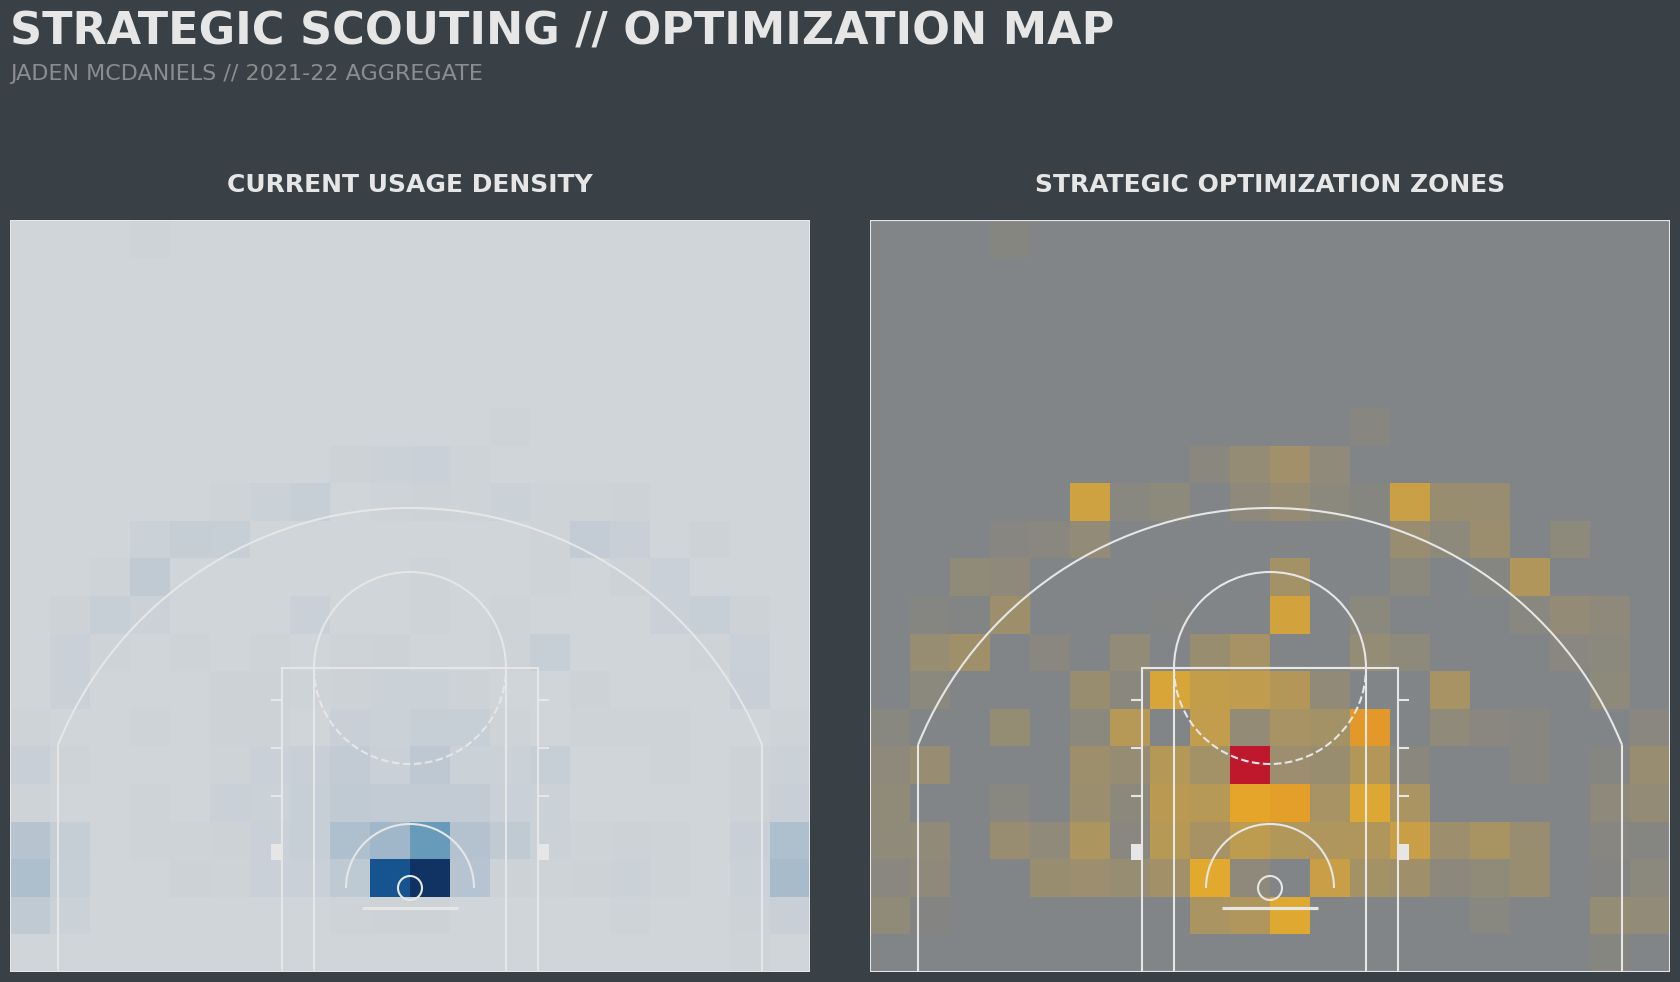

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import RegularPolygon
from matplotlib.colors import LinearSegmentedColormap
from google.cloud import bigquery
import seaborn as sns

# --- 1. BRAND & PALETTE SETTINGS ---
# Defining these globally ensures 'ind_optimization_scout' can find them
BRAND_DARK = '#394146'
BRAND_WHITE = '#E6E6E6'
BRAND_GREY = '#8A8D8F'
FOUL_HIGH = '#CF142B'

# --- 2. ACCURATE COURT GEOMETRY ---
def draw_court_accurate(ax, color='white', lw=1.5, paint_fill_color=None):
    """Standardized NBA half-court with redundant color definitions removed."""
    if paint_fill_color:
        ax.add_patch(patches.Rectangle((-80, -52.5), 160, 190, facecolor=paint_fill_color, alpha=0.25, zorder=1))

    # Base Court Outlines
    ax.add_patch(patches.Rectangle((-250, -52.5), 500, 470, linewidth=lw, edgecolor=color, fill=False, zorder=10))
    ax.plot([-250, 250], [417.5, 417.5], color=color, lw=lw, zorder=10)

    # Paint Areas
    ax.add_patch(patches.Rectangle((-80, -52.5), 160, 190, linewidth=lw, edgecolor=color, fill=False, zorder=10))
    ax.add_patch(patches.Rectangle((-60, -52.5), 120, 190, linewidth=lw, edgecolor=color, fill=False, zorder=10))

    # Arcs & Circles
    ax.add_patch(patches.Arc((0, 137.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color, zorder=10))
    ax.add_patch(patches.Arc((0, 137.5), 120, 120, theta1=180, theta2=360, linewidth=lw, color=color, linestyle='dashed', zorder=10))
    ax.add_patch(patches.Circle((0, 0), radius=7.5, linewidth=lw, edgecolor=color, fill=False, zorder=10))
    ax.plot([-30, 30], [-12.5, -12.5], color=color, lw=lw*1.5, zorder=10)
    ax.add_patch(patches.Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color, zorder=10))

    # 3-Point Lines
    ax.plot([-220, -220], [-52.5, 89.477], color=color, lw=lw, zorder=10)
    ax.plot([220, 220], [-52.5, 89.477], color=color, lw=lw, zorder=10)
    ax.add_patch(patches.Arc((0, 0), 475, 475, theta1=22.13, theta2=157.87, linewidth=lw, color=color, zorder=10))

    # Backboard/Rim Support (The Warning Fix)
    # Using 'facecolor' only since 'color' is redundant here
    ax.add_patch(patches.Rectangle((-86.6, 17.5), 6.6, 10, linewidth=lw, facecolor=color, zorder=10))
    ax.add_patch(patches.Rectangle((80, 17.5), 6.6, 10, linewidth=lw, facecolor=color, zorder=10))

    for y_val in [57.5, 87.5, 117.5]:
        ax.plot([-80, -86.6], [y_val, y_val], color=color, lw=lw, zorder=10)
        ax.plot([80, 86.6], [y_val, y_val], color=color, lw=lw, zorder=10)

    return ax

# --- 3. THE STRATEGIC OPTIMIZATION FUNCTION ---
def ind_optimization_scout(player_id, year):
    client = bigquery.Client(project=PROJECT_ID)
    season_title = f"{year-1}-{str(year)[-2:]}"

    # Fetch Metadata
    query_meta = f"SELECT full_name as player_name FROM `{PROJECT_ID}.{DATASET_ID}.dim_player_seasons` WHERE player_id = '{player_id}' LIMIT 1"
    player_name = client.query(query_meta).to_dataframe().iloc[0]['player_name']

    # Fetch Player Shots
    df_p = df_filtered[(df_filtered['player_id'] == player_id) & (df_filtered['season_year'] == year)]

    # Spatial Processing
    grid_size, extent = 20, [-250, 250, -52.5, 417.5]
    shots, _, _ = np.histogram2d(df_p['loc_x'], df_p['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])
    makes, _, _ = np.histogram2d(df_p[df_p['is_made']==1]['loc_x'], df_p[df_p['is_made']==1]['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])

    # Model Prediction
    spatial_in = np.expand_dims(np.stack([shots, makes], axis=-1) / 138.0, axis=0)
    tab_in = df_p[['height_scaled', 'weight_scaled', 'exp_scaled', 'ft_pct_scaled']].iloc[0:1].values
    pred_map = foul_model.predict([spatial_in, tab_in], verbose=0)[0, :, :, 0]

    # Strategic Value Math
    eff_map = (makes + 0.5) / (shots + 1.0)
    p_delta = df_analysis[df_analysis['player_id'] == player_id]['foul_delta'].mean() / len(df_p)
    foul_prob = (pred_map / (shots + 1.0)) + p_delta
    headroom = 1.0 - (shots / np.max(shots))
    sv_map = (eff_map * foul_prob * headroom)
    sv_map[shots == 0] = 0

    # Rendering with High-Fidelity Geometry
    fig = plt.figure(figsize=(20, 12), facecolor=BRAND_DARK)
    opt_cmap = LinearSegmentedColormap.from_list("opt", [BRAND_GREY, "#FDB927", FOUL_HIGH])

    ax1 = fig.add_axes([0.05, 0.08, 0.4, 0.82], facecolor=BRAND_DARK)
    draw_court_accurate(ax1, color=BRAND_WHITE, lw=1.5)
    ax1.imshow(shots.T, origin='lower', extent=extent, cmap='Blues', alpha=0.8, zorder=2)
    ax1.set_title("CURRENT USAGE DENSITY", color=BRAND_WHITE, fontsize=18, weight='bold', pad=20)
    ax1.axis('off')

    ax2 = fig.add_axes([0.48, 0.08, 0.4, 0.82], facecolor=BRAND_DARK)
    draw_court_accurate(ax2, color=BRAND_WHITE, lw=1.5)
    im2 = ax2.imshow(sv_map.T, origin='lower', extent=extent, cmap=opt_cmap, alpha=0.9, zorder=2)
    ax2.set_title("STRATEGIC OPTIMIZATION ZONES", color=BRAND_WHITE, fontsize=18, weight='bold', pad=20)
    ax2.axis('off')

    # Sidebar Stats
    fig.text(0.05, 0.95, "STRATEGIC SCOUTING // OPTIMIZATION MAP", color=BRAND_WHITE, fontsize=32, weight='bold')
    fig.text(0.05, 0.92, f"{player_name.upper()} // {season_title} AGGREGATE", color=BRAND_GREY, fontsize=16)

    plt.show()

# --- 4. EXECUTE ---
ind_optimization_scout(player_id="1630183", year=2022)

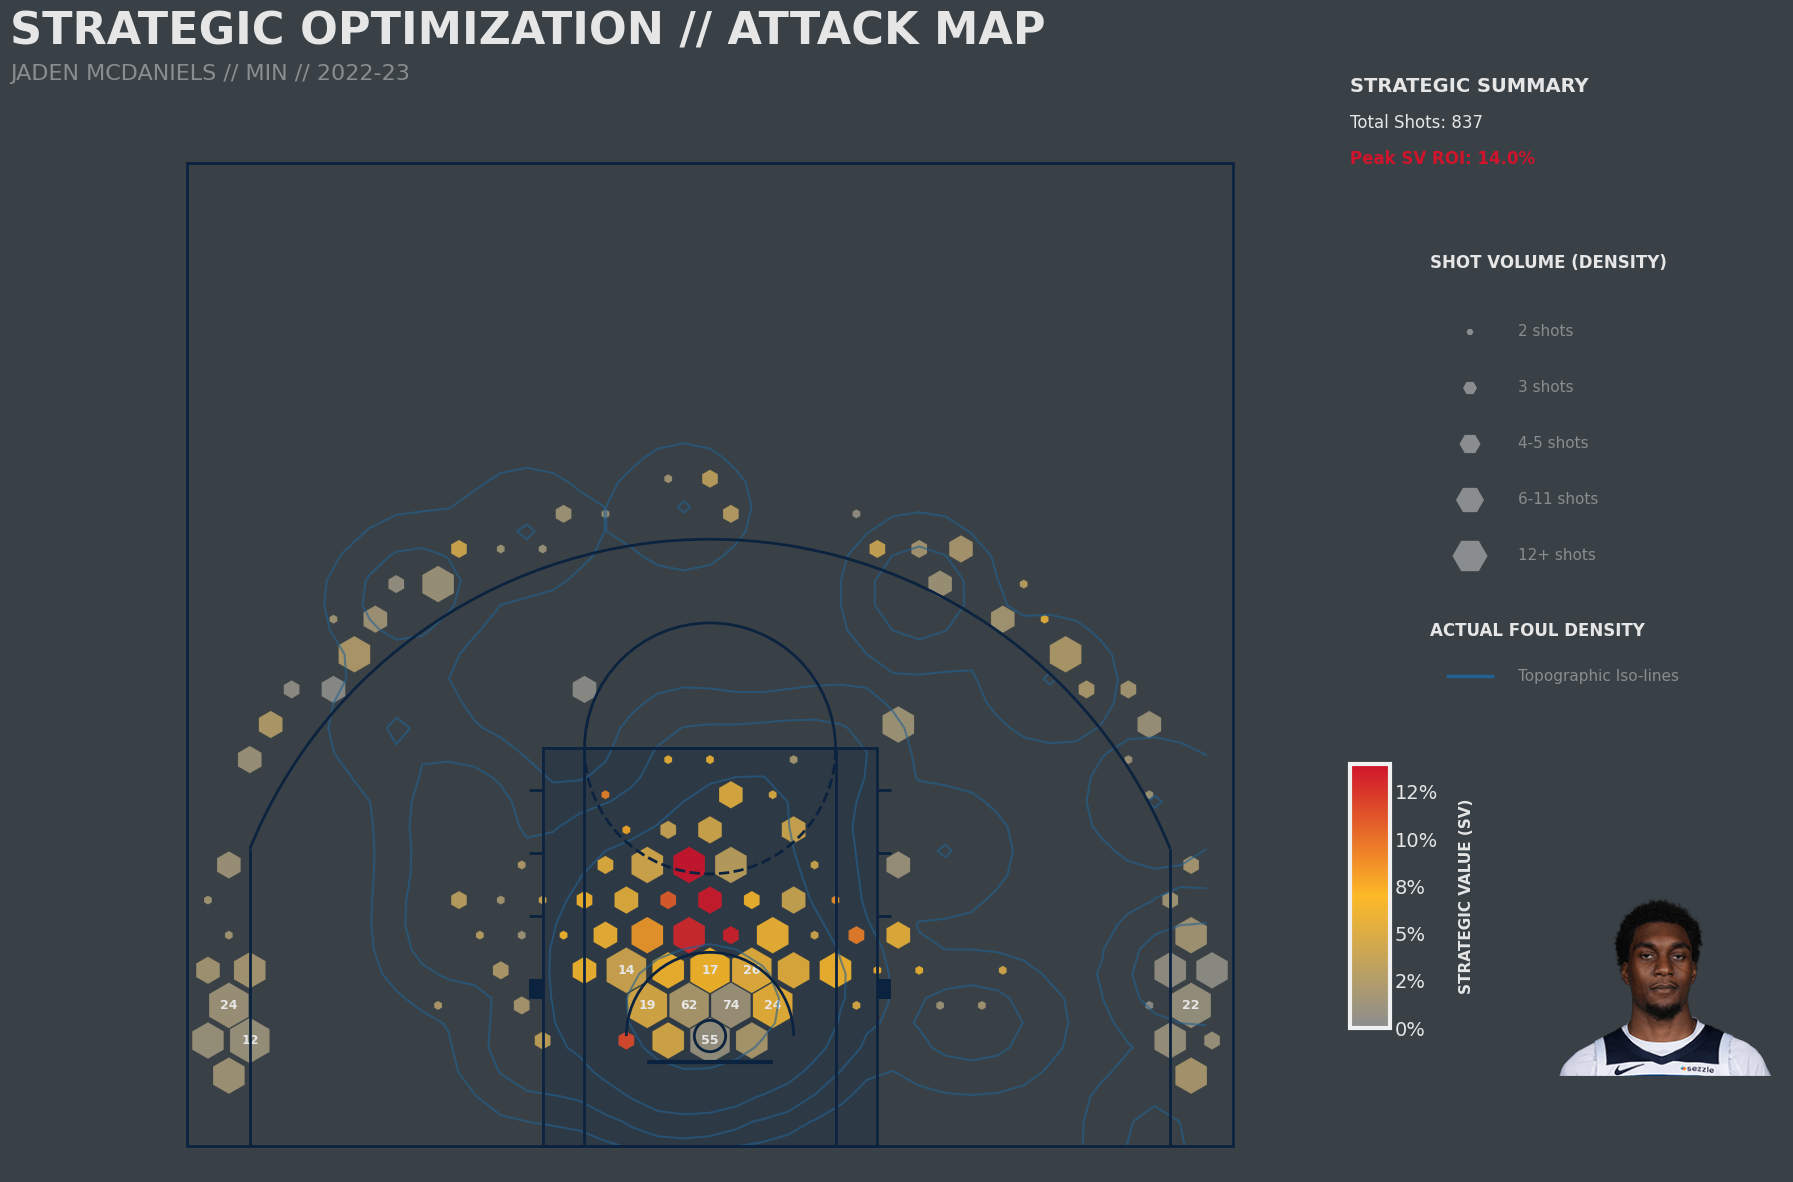

In [ ]:
import warnings
import requests
from PIL import Image
from io import BytesIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import RegularPolygon
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
import matplotlib.ticker as mtick
from google.cloud import bigquery

# Silence specific numpy warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning, module='numpy')

def ind_optimization_scout(player_id: str, year: int, df_filtered, df_analysis, foul_model):
    client = bigquery.Client(project=PROJECT_ID)

    # Updated NBA Season ID Logic: Combine Regular Season (2) and Playoffs (4)
    seasons_tuple = f"('2{year}', '4{year}')"
    season_title = f"{year}-{str(year+1)[-2:]}"

    # 1. Fetch Metadata & Colors (Checking both season IDs)
    query_meta = f"""
        SELECT p.full_name as player_name, t.team_abbr, t.primary_color, t.secondary_color
        FROM `{PROJECT_ID}.{DATASET_ID}.fct_shots` s
        JOIN `{PROJECT_ID}.{DATASET_ID}.dim_player_seasons` p ON s.player_id = p.player_id
        JOIN `{PROJECT_ID}.{DATASET_ID}.dim_teams` t ON s.team_id = t.team_id
        WHERE s.player_id = '{player_id}' AND s.season_id IN {seasons_tuple}
        LIMIT 1
    """
    try:
        meta = client.query(query_meta).to_dataframe().iloc[0]
        player_name, team_abbr = meta['player_name'], meta['team_abbr']
        primary, secondary = meta['primary_color'], meta['secondary_color']
    except Exception as e:
        print(f"Metadata fetch failed: {e}")
        return

    # 2. Data Processing & SV Math
    df_p = df_filtered[(df_filtered['player_id'] == player_id) & (df_filtered['season_year'] == year)].copy()
    grid_size, extent = 20, [-250, 250, -52.5, 417.5]

    shots_h, x_e, y_e = np.histogram2d(df_p['loc_x'], df_p['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])
    makes_h, _, _ = np.histogram2d(df_p[df_p['is_made']==1]['loc_x'], df_p[df_p['is_made']==1]['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])

    spatial_in = np.expand_dims(np.stack([shots_h, makes_h], axis=-1) / 138.0, axis=0)
    tab_in = df_p[['height_scaled', 'weight_scaled', 'exp_scaled', 'ft_pct_scaled']].iloc[0:1].values
    pred_map = foul_model.predict([spatial_in, tab_in], verbose=0)[0, :, :, 0]

    eff_map = (makes_h + 0.5) / (shots_h + 1.0)
    p_delta = df_analysis[df_analysis['player_id'] == player_id]['foul_delta'].mean() / len(df_p)
    foul_prob = (pred_map / (shots_h + 1.0)) + p_delta
    headroom = 1.0 - (shots_h / np.max(shots_h))
    sv_grid = eff_map * foul_prob * headroom

    x_bins = np.clip(np.digitize(df_p['loc_x'], x_e) - 1, 0, grid_size - 1)
    y_bins = np.clip(np.digitize(df_p['loc_y'], y_e) - 1, 0, grid_size - 1)
    df_p['sv_val'] = sv_grid[x_bins, y_bins]

    # 3. Hexbin Aggregation
    plt.ioff()
    hb = plt.hexbin(df_p['loc_x'], df_p['loc_y'], C=df_p['sv_val'], gridsize=25, extent=extent, mincnt=2, visible=False)
    verts, sv_rates = hb.get_offsets(), hb.get_array()
    hb_c = plt.hexbin(df_p['loc_x'], df_p['loc_y'], gridsize=25, extent=extent, mincnt=2, visible=False)
    counts = hb_c.get_array()
    plt.close()

    # 4. Strictly 5 Percentile Tiers
    p15, p35, p65, p90 = np.percentile(counts, [15, 35, 65, 90])

    def get_rank(val):
        if val <= p15: return 1
        elif val <= p35: return 2
        elif val <= p65: return 3
        elif val <= p90: return 4
        else: return 5

    ranks = np.array([get_rank(x) for x in counts])
    sv_max = sv_rates.max()
    MAX_R = (20.0 / np.sqrt(3)) * 0.95

    # 5. RENDERING LAYOUT
    fig = plt.figure(figsize=(20, 12), facecolor=BRAND_DARK)

    # Pushed Court Area limits based on your request
    ax_main = fig.add_axes([0.0, 0.0, 0.8, 0.95], facecolor=BRAND_DARK)
    ax_main.set_aspect('equal')

    opt_cmap = LinearSegmentedColormap.from_list("opt", [BRAND_GREY, "#FDB927", FOUL_HIGH])

    # Draw Court Hexes
    for pos, rank, rate, count in zip(verts, ranks, sv_rates, counts):
        radius = (rank / 5) * MAX_R
        color = opt_cmap(min(rate / sv_max, 1.0))
        ax_main.add_patch(RegularPolygon(pos, 6, radius=radius, orientation=0,
                                         facecolor=color, edgecolor=BRAND_DARK,
                                         linewidth=0.2, alpha=0.9, zorder=2))

        # New Feature: Annotate actual shot count on the largest hexes
        if rank == 5:
            ax_main.text(pos[0], pos[1], str(int(count)),
                         ha='center', va='center', color=BRAND_WHITE,
                         fontsize=9, weight='bold', zorder=3)

    # Court & Topography Overlay
    df_f = df_p[df_p['is_foul_drawn'] == 1]
    cnts, xe, ye = np.histogram2d(df_f['loc_x'], df_f['loc_y'], bins=40, range=[[-250, 250], [-52.5, 417.5]])
    smoothed = gaussian_filter(cnts, sigma=1.5)
    if smoothed.max() > 0:
        X, Y = np.meshgrid(xe[:-1], ye[:-1])
        lvls = np.percentile(smoothed[smoothed > 0], [50, 75, 90, 98])
        ax_main.contour(X, Y, smoothed.T, levels=lvls, colors=secondary, linewidths=1.5, alpha=0.6, zorder=6)

    draw_court_accurate(ax_main, color=primary, lw=2, paint_fill_color=primary)
    ax_main.set_xlim(-260, 260); ax_main.set_ylim(-65, 480); ax_main.axis('off')

    # 6. HEADERS & SUMMARY STATS
    fig.text(0.05, 0.94, "STRATEGIC OPTIMIZATION // ATTACK MAP", color=BRAND_WHITE, fontsize=32, weight='bold')
    fig.text(0.05, 0.91, f"{player_name.upper()} // {team_abbr} // {season_title}", color=BRAND_GREY, fontsize=16)

    fig.text(0.72, 0.90, "STRATEGIC SUMMARY", color=BRAND_WHITE, fontsize=14, weight='bold')
    fig.text(0.72, 0.87, f"Total Shots: {len(df_p):,}", color=BRAND_WHITE, fontsize=12)
    fig.text(0.72, 0.84, f"Peak SV ROI: {sv_max*100:.1f}%", color=FOUL_HIGH, fontsize=12, weight='bold')

    # 7. SEPARATED LEGENDS

    # A. Volume & Contour Legend
    ax_leg = fig.add_axes([0.72, 0.38, 0.20, 0.40], facecolor=BRAND_DARK)
    ax_leg.set_aspect('equal')
    ax_leg.axis('off')
    ax_leg.set_xlim(0, 150)
    ax_leg.set_ylim(0, 300)

    ax_leg.text(0, 280, "SHOT VOLUME (DENSITY)", color=BRAND_WHITE, weight='bold', size=12)

    bounds = [2, p15, p35, p65, p90, counts.max()]
    labels = []
    prev_val = 2
    for i in range(1, 6):
        high_val = max(int(bounds[i]), prev_val)
        if i == 5:
            labels.append(f"{prev_val}+ shots")
        elif prev_val == high_val:
            labels.append(f"{prev_val} shots")
        else:
            labels.append(f"{prev_val}-{high_val} shots")
        prev_val = high_val + 1

    for i in range(5):
        y_pos = 240 - (i * 35)
        r_val = ((i+1)/5) * MAX_R
        ax_leg.add_patch(RegularPolygon((25, y_pos), 6, radius=r_val, orientation=np.pi/2, facecolor=BRAND_GREY))
        ax_leg.text(55, y_pos, labels[i], color=BRAND_GREY, size=11, va='center')

    # Contour Explanation
    ax_leg.text(0, 50, "ACTUAL FOUL DENSITY", color=BRAND_WHITE, weight='bold', size=12)
    ax_leg.plot([10, 40], [25, 25], color=secondary, lw=2.5)
    ax_leg.text(55, 25, "Topographic Iso-lines", color=BRAND_GREY, size=11, va='center')

    # B. Strategic Value Gradient Colorbar
    cb_ax = fig.add_axes([0.72, 0.12, 0.02, 0.22])
    sm = plt.cm.ScalarMappable(cmap=opt_cmap, norm=plt.Normalize(vmin=0, vmax=sv_max*100))
    cb = fig.colorbar(sm, cax=cb_ax, format='%.0f%%')
    cb.set_label('STRATEGIC VALUE (SV)', color=BRAND_WHITE, size=11, weight='bold', labelpad=15)
    cb.ax.yaxis.set_tick_params(color=BRAND_WHITE, labelcolor=BRAND_WHITE)

    # 8. PLAYER HEADSHOT
    try:
        url = f"https://ak-static.cms.nba.com/wp-content/uploads/headshots/nba/latest/260x190/{player_id}.png"
        headshot = Image.open(BytesIO(requests.get(url).content))
        ax_photo = fig.add_axes([0.80, 0.08, 0.15, 0.15])
        ax_photo.imshow(headshot)
        ax_photo.axis('off')
    except:
        pass

    plt.show()

# --- EXECUTE ---
ind_optimization_scout(
    player_id="1630183",
    year=2022,
    df_filtered=df_filtered,
    df_analysis=df_analysis,
    foul_model=foul_model
)

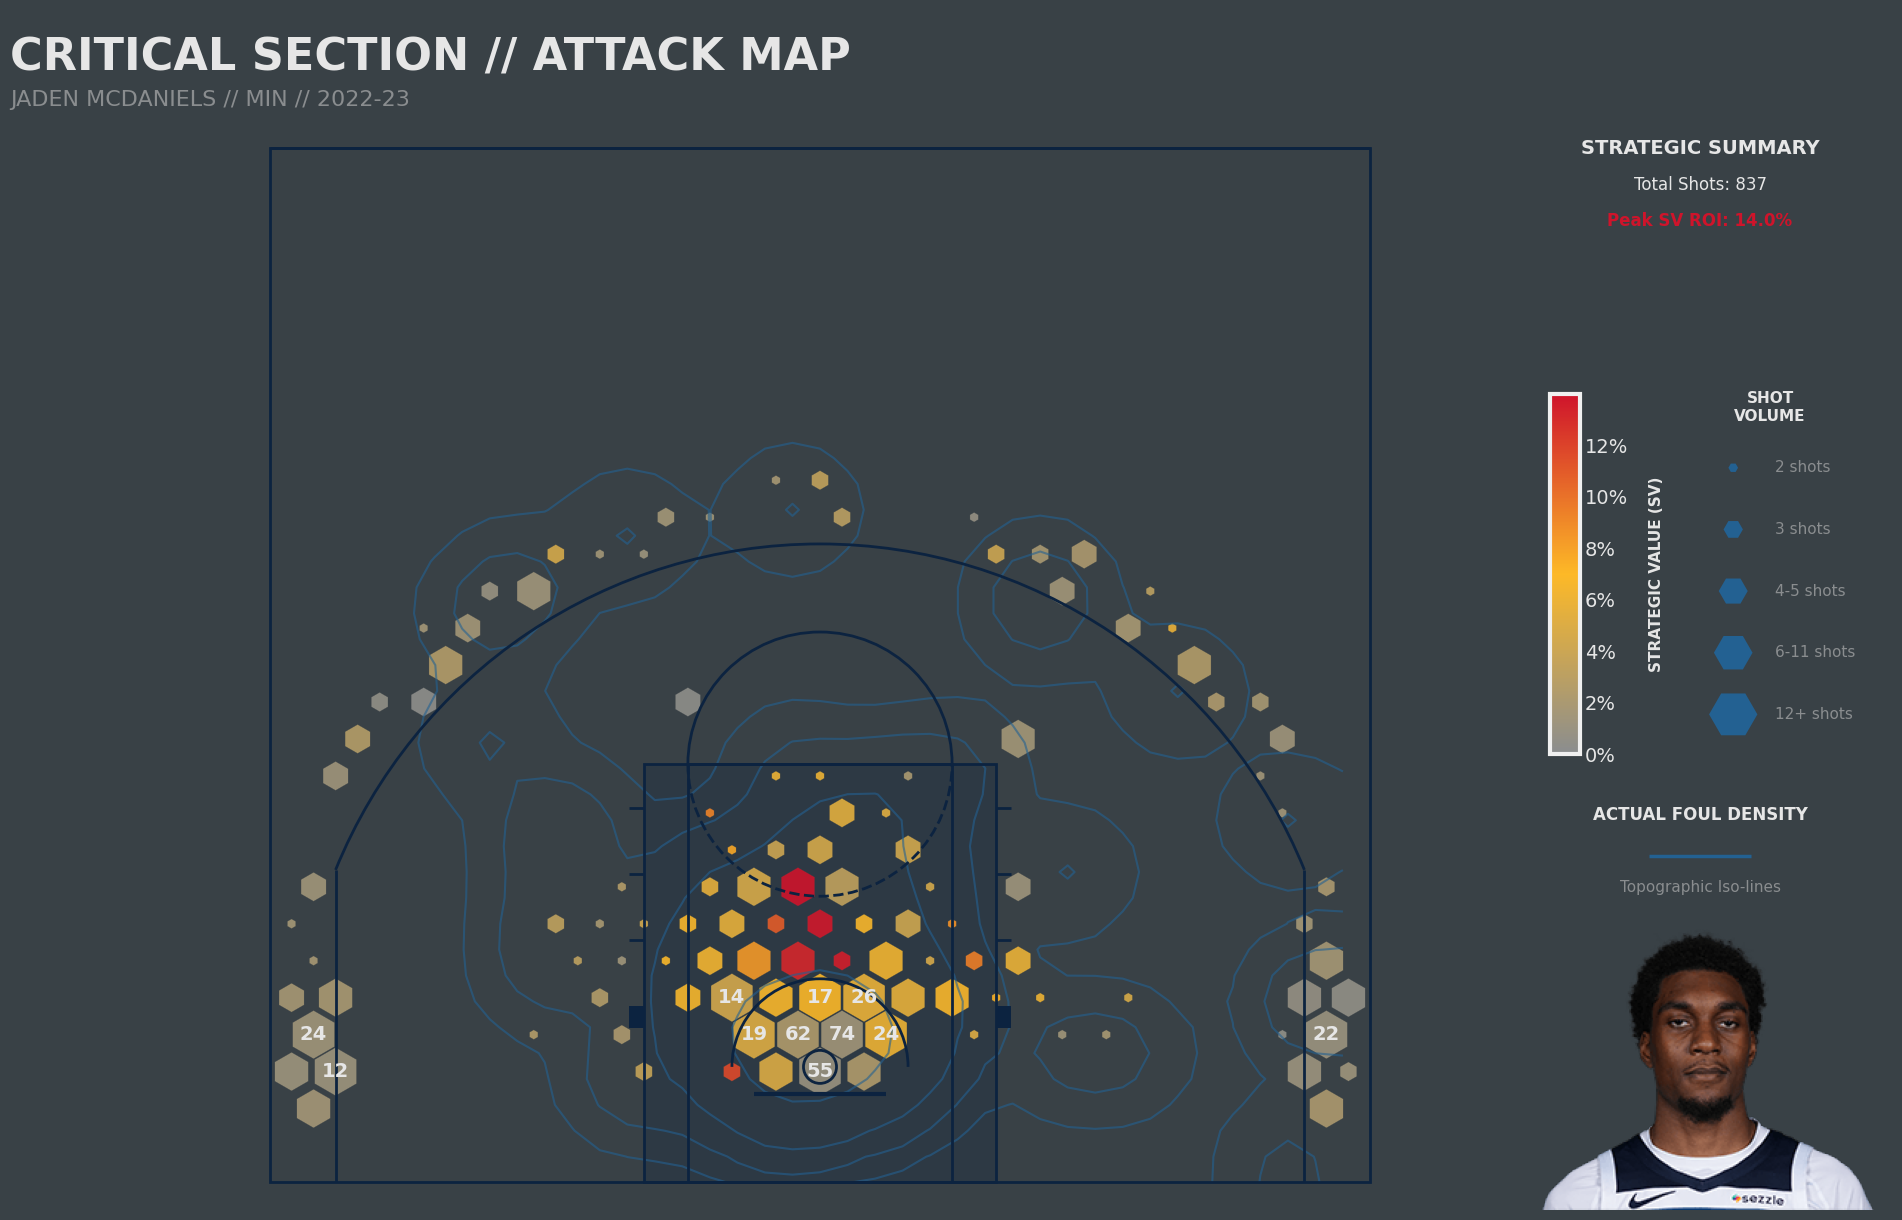

In [ ]:
import warnings
import requests
from PIL import Image
from io import BytesIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import RegularPolygon
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
import matplotlib.ticker as mtick
from google.cloud import bigquery

# Silence specific numpy warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning, module='numpy')

def ind_optimization_scout(player_id: str, year: int, df_filtered, df_analysis, foul_model):
    client = bigquery.Client(project=PROJECT_ID)

    seasons_tuple = f"('2{year}', '4{year}')"
    season_title = f"{year}-{str(year+1)[-2:]}"

    # 1. Fetch Metadata & Colors
    query_meta = f"""
        SELECT p.full_name as player_name, t.team_abbr, t.primary_color, t.secondary_color
        FROM `{PROJECT_ID}.{DATASET_ID}.fct_shots` s
        JOIN `{PROJECT_ID}.{DATASET_ID}.dim_player_seasons` p ON s.player_id = p.player_id
        JOIN `{PROJECT_ID}.{DATASET_ID}.dim_teams` t ON s.team_id = t.team_id
        WHERE s.player_id = '{player_id}' AND s.season_id IN {seasons_tuple}
        LIMIT 1
    """
    try:
        meta = client.query(query_meta).to_dataframe().iloc[0]
        player_name, team_abbr = meta['player_name'], meta['team_abbr']
        primary, secondary = meta['primary_color'], meta['secondary_color']
    except Exception as e:
        print(f"Metadata fetch failed: {e}")
        return

    # 2. Data Processing & SV Math
    df_p = df_filtered[(df_filtered['player_id'] == player_id) & (df_filtered['season_year'] == year)].copy()
    grid_size, extent = 20, [-250, 250, -52.5, 417.5]

    shots_h, x_e, y_e = np.histogram2d(df_p['loc_x'], df_p['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])
    makes_h, _, _ = np.histogram2d(df_p[df_p['is_made']==1]['loc_x'], df_p[df_p['is_made']==1]['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])

    spatial_in = np.expand_dims(np.stack([shots_h, makes_h], axis=-1) / 138.0, axis=0)
    tab_in = df_p[['height_scaled', 'weight_scaled', 'exp_scaled', 'ft_pct_scaled']].iloc[0:1].values
    pred_map = foul_model.predict([spatial_in, tab_in], verbose=0)[0, :, :, 0]

    eff_map = (makes_h + 0.5) / (shots_h + 1.0)
    p_delta = df_analysis[df_analysis['player_id'] == player_id]['foul_delta'].mean() / len(df_p)
    foul_prob = (pred_map / (shots_h + 1.0)) + p_delta
    headroom = 1.0 - (shots_h / np.max(shots_h))
    sv_grid = eff_map * foul_prob * headroom

    x_bins = np.clip(np.digitize(df_p['loc_x'], x_e) - 1, 0, grid_size - 1)
    y_bins = np.clip(np.digitize(df_p['loc_y'], y_e) - 1, 0, grid_size - 1)
    df_p['sv_val'] = sv_grid[x_bins, y_bins]

    # 3. Hexbin Aggregation
    plt.ioff()
    hb = plt.hexbin(df_p['loc_x'], df_p['loc_y'], C=df_p['sv_val'], gridsize=25, extent=extent, mincnt=2, visible=False)
    verts, sv_rates = hb.get_offsets(), hb.get_array()
    hb_c = plt.hexbin(df_p['loc_x'], df_p['loc_y'], gridsize=25, extent=extent, mincnt=2, visible=False)
    counts = hb_c.get_array()
    plt.close()

    # 4. Strictly 5 Percentile Tiers
    p15, p35, p65, p90 = np.percentile(counts, [15, 35, 65, 90])
    def get_rank(val):
        if val <= p15: return 1
        elif val <= p35: return 2
        elif val <= p65: return 3
        elif val <= p90: return 4
        else: return 5

    ranks = np.array([get_rank(x) for x in counts])
    sv_max = sv_rates.max()
    MAX_R = (20.0 / np.sqrt(3)) * 0.95

    # 5. RENDERING LAYOUT
    fig = plt.figure(figsize=(20, 12), facecolor=BRAND_DARK)

    # Fully expanded court pushing into the top margin safely
    ax_main = fig.add_axes([0.0, 0.0, 0.85, 1.0], facecolor=BRAND_DARK)
    ax_main.set_aspect('equal')

    opt_cmap = LinearSegmentedColormap.from_list("opt", [BRAND_GREY, "#FDB927", FOUL_HIGH])

    # Draw Court Hexes
    for pos, rank, rate, count in zip(verts, ranks, sv_rates, counts):
        radius = (rank / 5) * MAX_R
        color = opt_cmap(min(rate / sv_max, 1.0))
        ax_main.add_patch(RegularPolygon(pos, 6, radius=radius, orientation=0,
                                         facecolor=color, edgecolor=BRAND_DARK,
                                         linewidth=0.2, alpha=0.9, zorder=2))

        # High Z-Order and size 14 font for maximum clarity
        if rank == 5:
            ax_main.text(pos[0], pos[1], str(int(count)),
                         ha='center', va='center', color=BRAND_WHITE,
                         fontsize=14, weight='bold', zorder=20)

    # Court & Topography Overlay
    df_f = df_p[df_p['is_foul_drawn'] == 1]
    cnts, xe, ye = np.histogram2d(df_f['loc_x'], df_f['loc_y'], bins=40, range=[[-250, 250], [-52.5, 417.5]])
    smoothed = gaussian_filter(cnts, sigma=1.5)
    if smoothed.max() > 0:
        X, Y = np.meshgrid(xe[:-1], ye[:-1])
        lvls = np.percentile(smoothed[smoothed > 0], [50, 75, 90, 98])
        ax_main.contour(X, Y, smoothed.T, levels=lvls, colors=secondary, linewidths=1.5, alpha=0.6, zorder=6)

    draw_court_accurate(ax_main, color=primary, lw=2, paint_fill_color=primary)
    ax_main.set_xlim(-260, 260); ax_main.set_ylim(-65, 480); ax_main.axis('off')

    # 6. HEADERS
    fig.text(0.02, 0.95, "CRITICAL SECTION // ATTACK MAP", color=BRAND_WHITE, fontsize=32, weight='bold')
    fig.text(0.02, 0.92, f"{player_name.upper()} // {team_abbr} // {season_title}", color=BRAND_GREY, fontsize=16)

    # ---------------------------------------------------------
    # 7. SIDEBAR ALIGNMENT
    # ---------------------------------------------------------
    center_x = 0.865

    # A. Strategic Summary
    fig.text(center_x, 0.88, "STRATEGIC SUMMARY", color=BRAND_WHITE, fontsize=14, weight='bold', ha='center')
    fig.text(center_x, 0.85, f"Total Shots: {len(df_p):,}", color=BRAND_WHITE, fontsize=12, ha='center')
    fig.text(center_x, 0.82, f"Peak SV ROI: {sv_max*100:.1f}%", color=FOUL_HIGH, fontsize=12, weight='bold', ha='center')

    # B. Legends Side-by-Side

    # LEFT: SV Colorbar Gradient
    cb_ax = fig.add_axes([0.79, 0.38, 0.015, 0.30])
    sm = plt.cm.ScalarMappable(cmap=opt_cmap, norm=plt.Normalize(vmin=0, vmax=sv_max*100))
    cb = fig.colorbar(sm, cax=cb_ax, format='%.0f%%')
    cb.set_label('STRATEGIC VALUE (SV)', color=BRAND_WHITE, size=11, weight='bold', labelpad=15)
    cb.ax.yaxis.set_tick_params(color=BRAND_WHITE, labelcolor=BRAND_WHITE)

    # RIGHT: Shot Volume Hexes (Synchronized Data Limits to 1.0 Height Scale)
    ax_leg = fig.add_axes([0.84, 0.38, 0.12, 0.30], facecolor=BRAND_DARK)
    ax_leg.set_aspect('equal')
    ax_leg.axis('off')

    # Exact synchronized scaling math: Y_lim = 545 * 0.30 = 163.5, X_lim = 545 * 0.12 = 65.4
    ax_leg.set_xlim(0, 65.4)
    ax_leg.set_ylim(0, 163.5)

    ax_leg.text(32.7, 150, "SHOT\nVOLUME", color=BRAND_WHITE, weight='bold', size=11, ha='center', va='bottom')

    bounds = [2, p15, p35, p65, p90, counts.max()]
    labels = []
    prev_val = 2
    for i in range(1, 6):
        high_val = max(int(bounds[i]), prev_val)
        if i == 5: labels.append(f"{prev_val}+ shots")
        elif prev_val == high_val: labels.append(f"{prev_val} shots")
        else: labels.append(f"{prev_val}-{high_val} shots")
        prev_val = high_val + 1

    # Adjusted Y positions to fit cleanly inside the 163.5 limit
    for i in range(5):
        y_pos = 130 - (i * 28)
        r_val = ((i+1)/5) * MAX_R
        ax_leg.add_patch(RegularPolygon((16, y_pos), 6, radius=r_val, orientation=np.pi/2, facecolor=secondary))
        ax_leg.text(35, y_pos, labels[i], color=BRAND_GREY, size=11, va='center')

    # C. Actual Foul Density Contour Legend
    ax_contour = fig.add_axes([0.77, 0.25, 0.19, 0.10], facecolor=BRAND_DARK)
    ax_contour.axis('off')
    ax_contour.set_xlim(0, 300)
    ax_contour.set_ylim(0, 100)

    ax_contour.text(150, 75, "ACTUAL FOUL DENSITY", color=BRAND_WHITE, weight='bold', size=12, ha='center')
    ax_contour.plot([110, 190], [45, 45], color=secondary, lw=2.5)
    ax_contour.text(150, 15, "Topographic Iso-lines", color=BRAND_GREY, size=11, ha='center')

    # D. Player Image
    try:
        url = f"https://ak-static.cms.nba.com/wp-content/uploads/headshots/nba/latest/260x190/{player_id}.png"
        headshot = Image.open(BytesIO(requests.get(url).content))
        ax_photo = fig.add_axes([0.748, 0.0, 0.234, 0.234])
        ax_photo.imshow(headshot)
        ax_photo.axis('off')
    except:
        pass

    plt.show()

# --- EXECUTE ---
ind_optimization_scout(
    player_id="1630183",
    year=2022,
    df_filtered=df_filtered,
    df_analysis=df_analysis,
    foul_model=foul_model
)

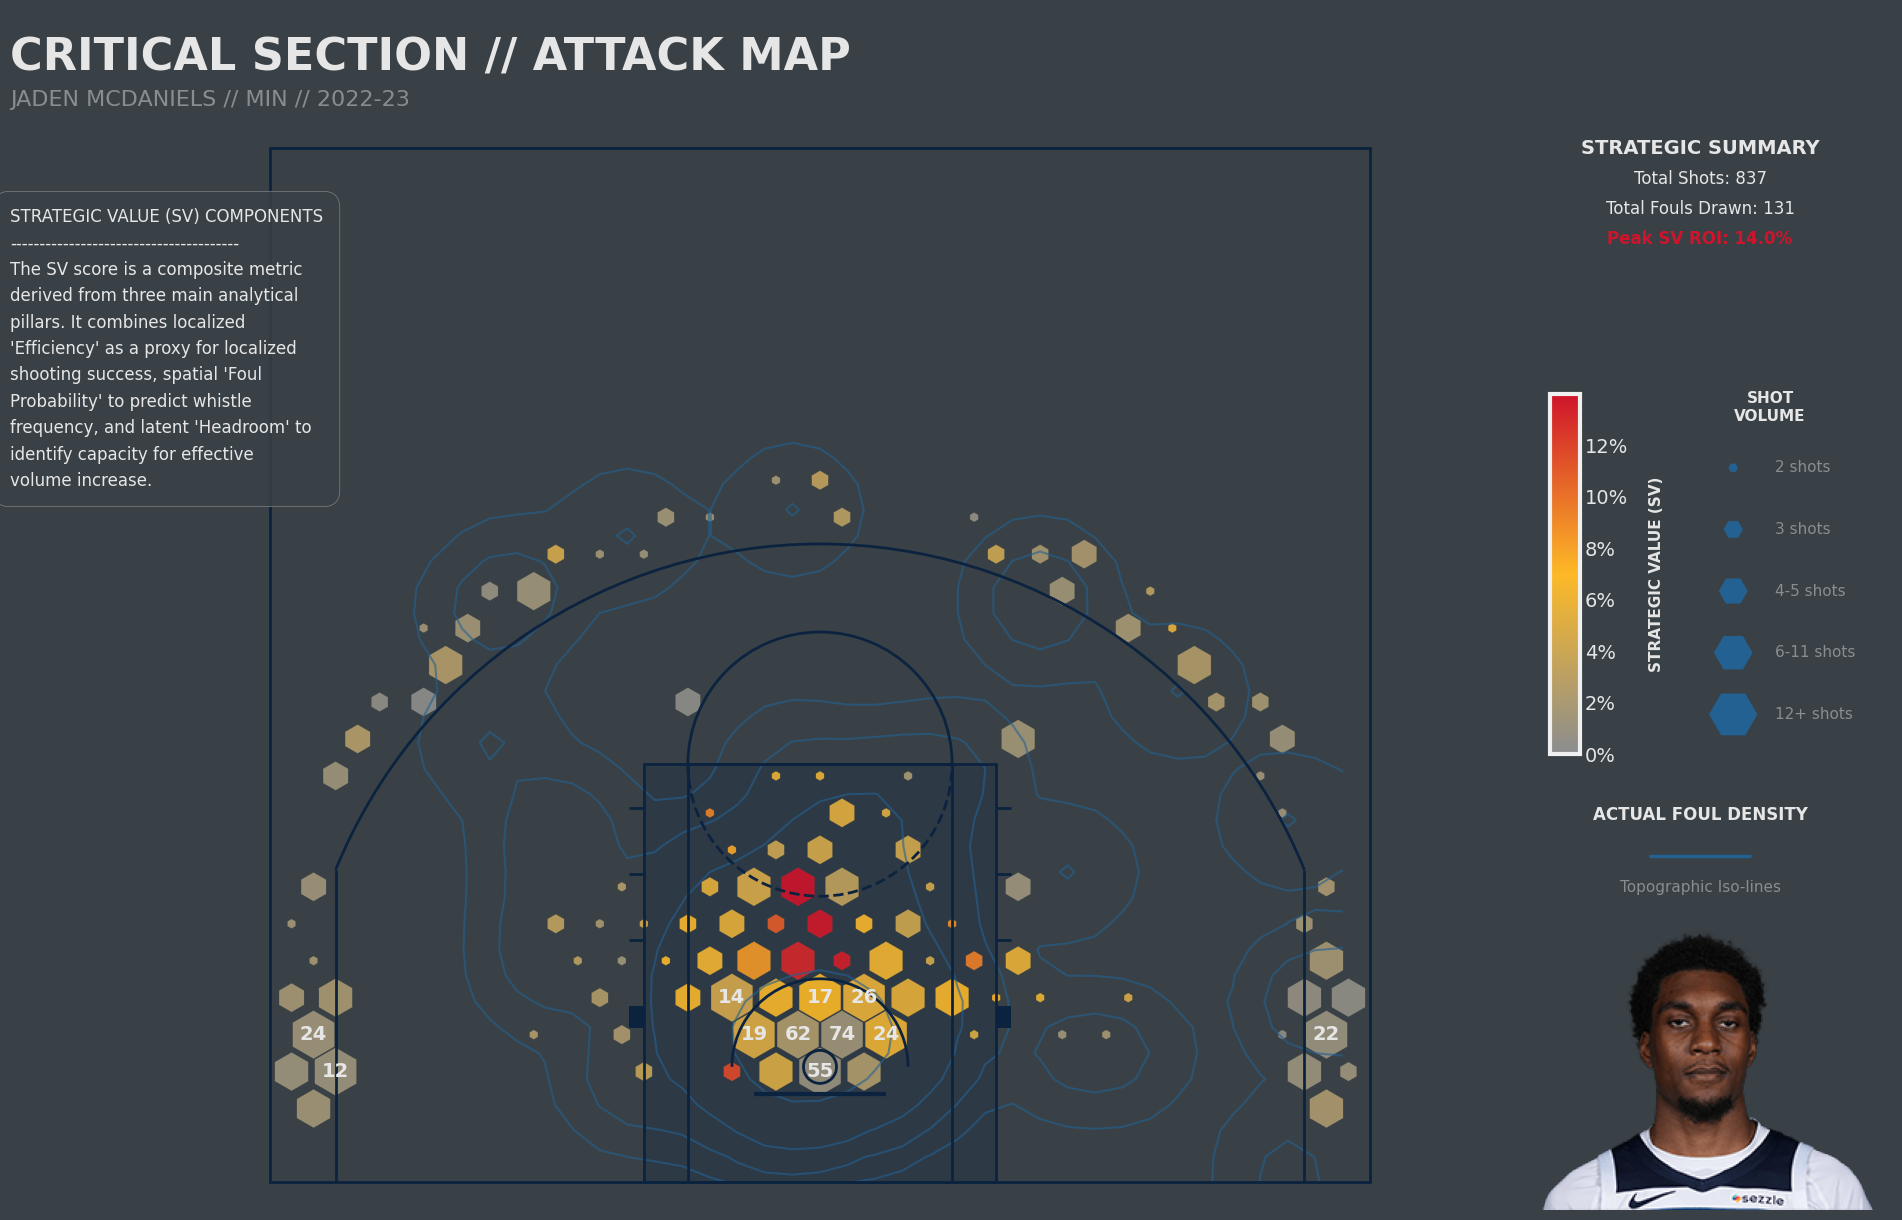

In [ ]:
import warnings
import requests
from PIL import Image
from io import BytesIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import RegularPolygon
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
import matplotlib.ticker as mtick
from google.cloud import bigquery

# Silence specific numpy warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning, module='numpy')

def ind_optimization_scout(player_id: str, year: int, df_filtered, df_analysis, foul_model):
    client = bigquery.Client(project=PROJECT_ID)

    # Combined Regular Season and Playoffs
    seasons_tuple = f"('2{year}', '4{year}')"
    season_title = f"{year}-{str(year+1)[-2:]}"

    # 1. Fetch Metadata & Colors
    query_meta = f"""
        SELECT p.full_name as player_name, t.team_abbr, t.primary_color, t.secondary_color
        FROM `{PROJECT_ID}.{DATASET_ID}.fct_shots` s
        JOIN `{PROJECT_ID}.{DATASET_ID}.dim_player_seasons` p ON s.player_id = p.player_id
        JOIN `{PROJECT_ID}.{DATASET_ID}.dim_teams` t ON s.team_id = t.team_id
        WHERE s.player_id = '{player_id}' AND s.season_id IN {seasons_tuple}
        LIMIT 1
    """
    try:
        meta = client.query(query_meta).to_dataframe().iloc[0]
        player_name, team_abbr = meta['player_name'], meta['team_abbr']
        primary, secondary = meta['primary_color'], meta['secondary_color']
    except Exception as e:
        print(f"Metadata fetch failed: {e}")
        return

    # 2. Data Processing & SV Math
    df_p = df_filtered[(df_filtered['player_id'] == player_id) & (df_filtered['season_year'] == year)].copy()
    grid_size, extent = 20, [-250, 250, -52.5, 417.5]

    shots_h, x_e, y_e = np.histogram2d(df_p['loc_x'], df_p['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])
    makes_h, _, _ = np.histogram2d(df_p[df_p['is_made']==1]['loc_x'], df_p[df_p['is_made']==1]['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])

    spatial_in = np.expand_dims(np.stack([shots_h, makes_h], axis=-1) / 138.0, axis=0)
    tab_in = df_p[['height_scaled', 'weight_scaled', 'exp_scaled', 'ft_pct_scaled']].iloc[0:1].values
    pred_map = foul_model.predict([spatial_in, tab_in], verbose=0)[0, :, :, 0]

    eff_map = (makes_h + 0.5) / (shots_h + 1.0)
    p_delta = df_analysis[df_analysis['player_id'] == player_id]['foul_delta'].mean() / len(df_p)
    foul_prob = (pred_map / (shots_h + 1.0)) + p_delta
    headroom = 1.0 - (shots_h / np.max(shots_h))
    sv_grid = eff_map * foul_prob * headroom

    x_bins = np.clip(np.digitize(df_p['loc_x'], x_e) - 1, 0, grid_size - 1)
    y_bins = np.clip(np.digitize(df_p['loc_y'], y_e) - 1, 0, grid_size - 1)
    df_p['sv_val'] = sv_grid[x_bins, y_bins]

    # 3. Hexbin Aggregation
    plt.ioff()
    hb = plt.hexbin(df_p['loc_x'], df_p['loc_y'], C=df_p['sv_val'], gridsize=25, extent=extent, mincnt=2, visible=False)
    verts, sv_rates = hb.get_offsets(), hb.get_array()
    hb_c = plt.hexbin(df_p['loc_x'], df_p['loc_y'], gridsize=25, extent=extent, mincnt=2, visible=False)
    counts = hb_c.get_array()
    plt.close()

    # 4. Strictly 5 Percentile Tiers
    p15, p35, p65, p90 = np.percentile(counts, [15, 35, 65, 90])
    def get_rank(val):
        if val <= p15: return 1
        elif val <= p35: return 2
        elif val <= p65: return 3
        elif val <= p90: return 4
        else: return 5

    ranks = np.array([get_rank(x) for x in counts])
    sv_max = sv_rates.max()
    MAX_R = (20.0 / np.sqrt(3)) * 0.95

    # 5. RENDERING LAYOUT
    fig = plt.figure(figsize=(20, 12), facecolor=BRAND_DARK)

    # Max court area on the final 20x12 canvas. Baked-in margins handle physical separation.
    ax_main = fig.add_axes([0.0, 0.0, 0.85, 1.0], facecolor=BRAND_DARK)
    ax_main.set_aspect('equal')

    opt_cmap = LinearSegmentedColormap.from_list("opt", [BRAND_GREY, "#FDB927", FOUL_HIGH])

    # Draw Court Hexes
    for pos, rank, rate, count in zip(verts, ranks, sv_rates, counts):
        radius = (rank / 5) * MAX_R
        color = opt_cmap(min(rate / sv_max, 1.0))
        ax_main.add_patch(RegularPolygon(pos, 6, radius=radius, orientation=0,
                                         facecolor=color, edgecolor=BRAND_DARK,
                                         linewidth=0.2, alpha=0.9, zorder=2))

        if rank == 5:
            ax_main.text(pos[0], pos[1], str(int(count)),
                         ha='center', va='center', color=BRAND_WHITE,
                         fontsize=14, weight='bold', zorder=20)

    # Court & Topography Overlay
    df_f = df_p[df_p['is_foul_drawn'] == 1]
    cnts, xe, ye = np.histogram2d(df_f['loc_x'], df_f['loc_y'], bins=40, range=[[-250, 250], [-52.5, 417.5]])
    smoothed = gaussian_filter(cnts, sigma=1.5)
    if smoothed.max() > 0:
        X, Y = np.meshgrid(xe[:-1], ye[:-1])
        lvls = np.percentile(smoothed[smoothed > 0], [50, 75, 90, 98])
        ax_main.contour(X, Y, smoothed.T, levels=lvls, colors=secondary, linewidths=1.5, alpha=0.6, zorder=6)

    draw_court_accurate(ax_main, color=primary, lw=2, paint_fill_color=primary)
    ax_main.set_xlim(-260, 260); ax_main.set_ylim(-65, 480); ax_main.axis('off')

    # 6. HEADERS & LEFT MARGIN CAPTION
    fig.text(0.02, 0.95, "CRITICAL SECTION // ATTACK MAP", color=BRAND_WHITE, fontsize=32, weight='bold')
    fig.text(0.02, 0.92, f"{player_name.upper()} // {team_abbr} // {season_title}", color=BRAND_GREY, fontsize=16)

    # REVISED Narrative SV Caption Box (Narrower and Taller)
    # Anchor to same location (0.02, 0.10) but manually insert line breaks to enforce width.
    sv_explanation = (
        "STRATEGIC VALUE (SV) COMPONENTS\n"
        "---------------------------------------\n"
        "The SV score is a composite metric\n"
        "derived from three main analytical\n"
        "pillars. It combines localized\n"
        "'Efficiency' as a proxy for localized\n"
        "shooting success, spatial 'Foul\n"
        "Probability' to predict whistle\n"
        "frequency, and latent 'Headroom' to\n"
        "identify capacity for effective\n"
        "volume increase."
    )
    fig.text(0.02, 0.60, sv_explanation, color=BRAND_WHITE, fontsize=12,
             ha='left', va='bottom', linespacing=1.6,
             bbox=dict(facecolor=BRAND_DARK, edgecolor=BRAND_GREY, boxstyle='round,pad=1', alpha=0.85))

    # ---------------------------------------------------------
    # 7. SIDEBAR ALIGNMENT
    # ---------------------------------------------------------
    center_x = 0.865

    # A. Strategic Summary
    fig.text(center_x, 0.88, "STRATEGIC SUMMARY", color=BRAND_WHITE, fontsize=14, weight='bold', ha='center')
    fig.text(center_x, 0.855, f"Total Shots: {len(df_p):,}", color=BRAND_WHITE, fontsize=12, ha='center')
    fig.text(center_x, 0.83, f"Total Fouls Drawn: {len(df_f):,}", color=BRAND_WHITE, fontsize=12, ha='center')
    fig.text(center_x, 0.805, f"Peak SV ROI: {sv_max*100:.1f}%", color=FOUL_HIGH, fontsize=12, weight='bold', ha='center')

    # B. Legends Side-by-Side

    # LEFT: SV Colorbar Gradient
    cb_ax = fig.add_axes([0.79, 0.38, 0.015, 0.30])
    sm = plt.cm.ScalarMappable(cmap=opt_cmap, norm=plt.Normalize(vmin=0, vmax=sv_max*100))
    cb = fig.colorbar(sm, cax=cb_ax, format='%.0f%%')
    cb.set_label('STRATEGIC VALUE (SV)', color=BRAND_WHITE, size=11, weight='bold', labelpad=15)
    cb.ax.yaxis.set_tick_params(color=BRAND_WHITE, labelcolor=BRAND_WHITE)

    # RIGHT: Shot Volume Hexes (Scale perfectly matched to 1.0 height court)
    ax_leg = fig.add_axes([0.84, 0.38, 0.12, 0.30], facecolor=BRAND_DARK)
    ax_leg.set_aspect('equal')
    ax_leg.axis('off')

    # Exact synchronized scaling math (Y_lim = 545 * 0.30 = 163.5, X_lim = 545 * 0.12 = 65.4)
    ax_leg.set_xlim(0, 65.4)
    ax_leg.set_ylim(0, 163.5)

    ax_leg.text(32.7, 150, "SHOT\nVOLUME", color=BRAND_WHITE, weight='bold', size=11, ha='center', va='bottom')

    bounds = [2, p15, p35, p65, p90, counts.max()]
    labels = []
    prev_val = 2
    for i in range(1, 6):
        high_val = max(int(bounds[i]), prev_val)
        if i == 5: labels.append(f"{prev_val}+ shots")
        elif prev_val == high_val: labels.append(f"{prev_val} shots")
        else: labels.append(f"{prev_val}-{high_val} shots")
        prev_val = high_val + 1

    # Adjusted Y positions to fit cleanly inside the 163.5 limit
    for i in range(5):
        y_pos = 130 - (i * 28)
        r_val = ((i+1)/5) * MAX_R
        ax_leg.add_patch(RegularPolygon((16, y_pos), 6, radius=r_val, orientation=np.pi/2, facecolor=secondary))
        ax_leg.text(35, y_pos, labels[i], color=BRAND_GREY, size=11, va='center')

    # C. Actual Foul Density Contour Legend
    ax_contour = fig.add_axes([0.77, 0.25, 0.19, 0.10], facecolor=BRAND_DARK)
    ax_contour.axis('off')
    ax_contour.set_xlim(0, 300)
    ax_contour.set_ylim(0, 100)

    ax_contour.text(150, 75, "ACTUAL FOUL DENSITY", color=BRAND_WHITE, weight='bold', size=12, ha='center')
    ax_contour.plot([110, 190], [45, 45], color=secondary, lw=2.5)
    ax_contour.text(150, 15, "Topographic Iso-lines", color=BRAND_GREY, size=11, ha='center')

    # D. Player Image (Size increased by 30%: 0.18 -> 0.234)
    # Centered squarely with the rest of the sidebar elements at 0.865
    try:
        url = f"https://ak-static.cms.nba.com/wp-content/uploads/headshots/nba/latest/260x190/{player_id}.png"
        headshot = Image.open(BytesIO(requests.get(url).content))
        ax_photo = fig.add_axes([0.748, 0.0, 0.234, 0.234])
        ax_photo.imshow(headshot)
        ax_photo.axis('off')
    except:
        pass

    plt.show()

# --- EXECUTE ---
ind_optimization_scout(
    player_id="1630183",
    year=2022,
    df_filtered=df_filtered,
    df_analysis=df_analysis,
    foul_model=foul_model
)

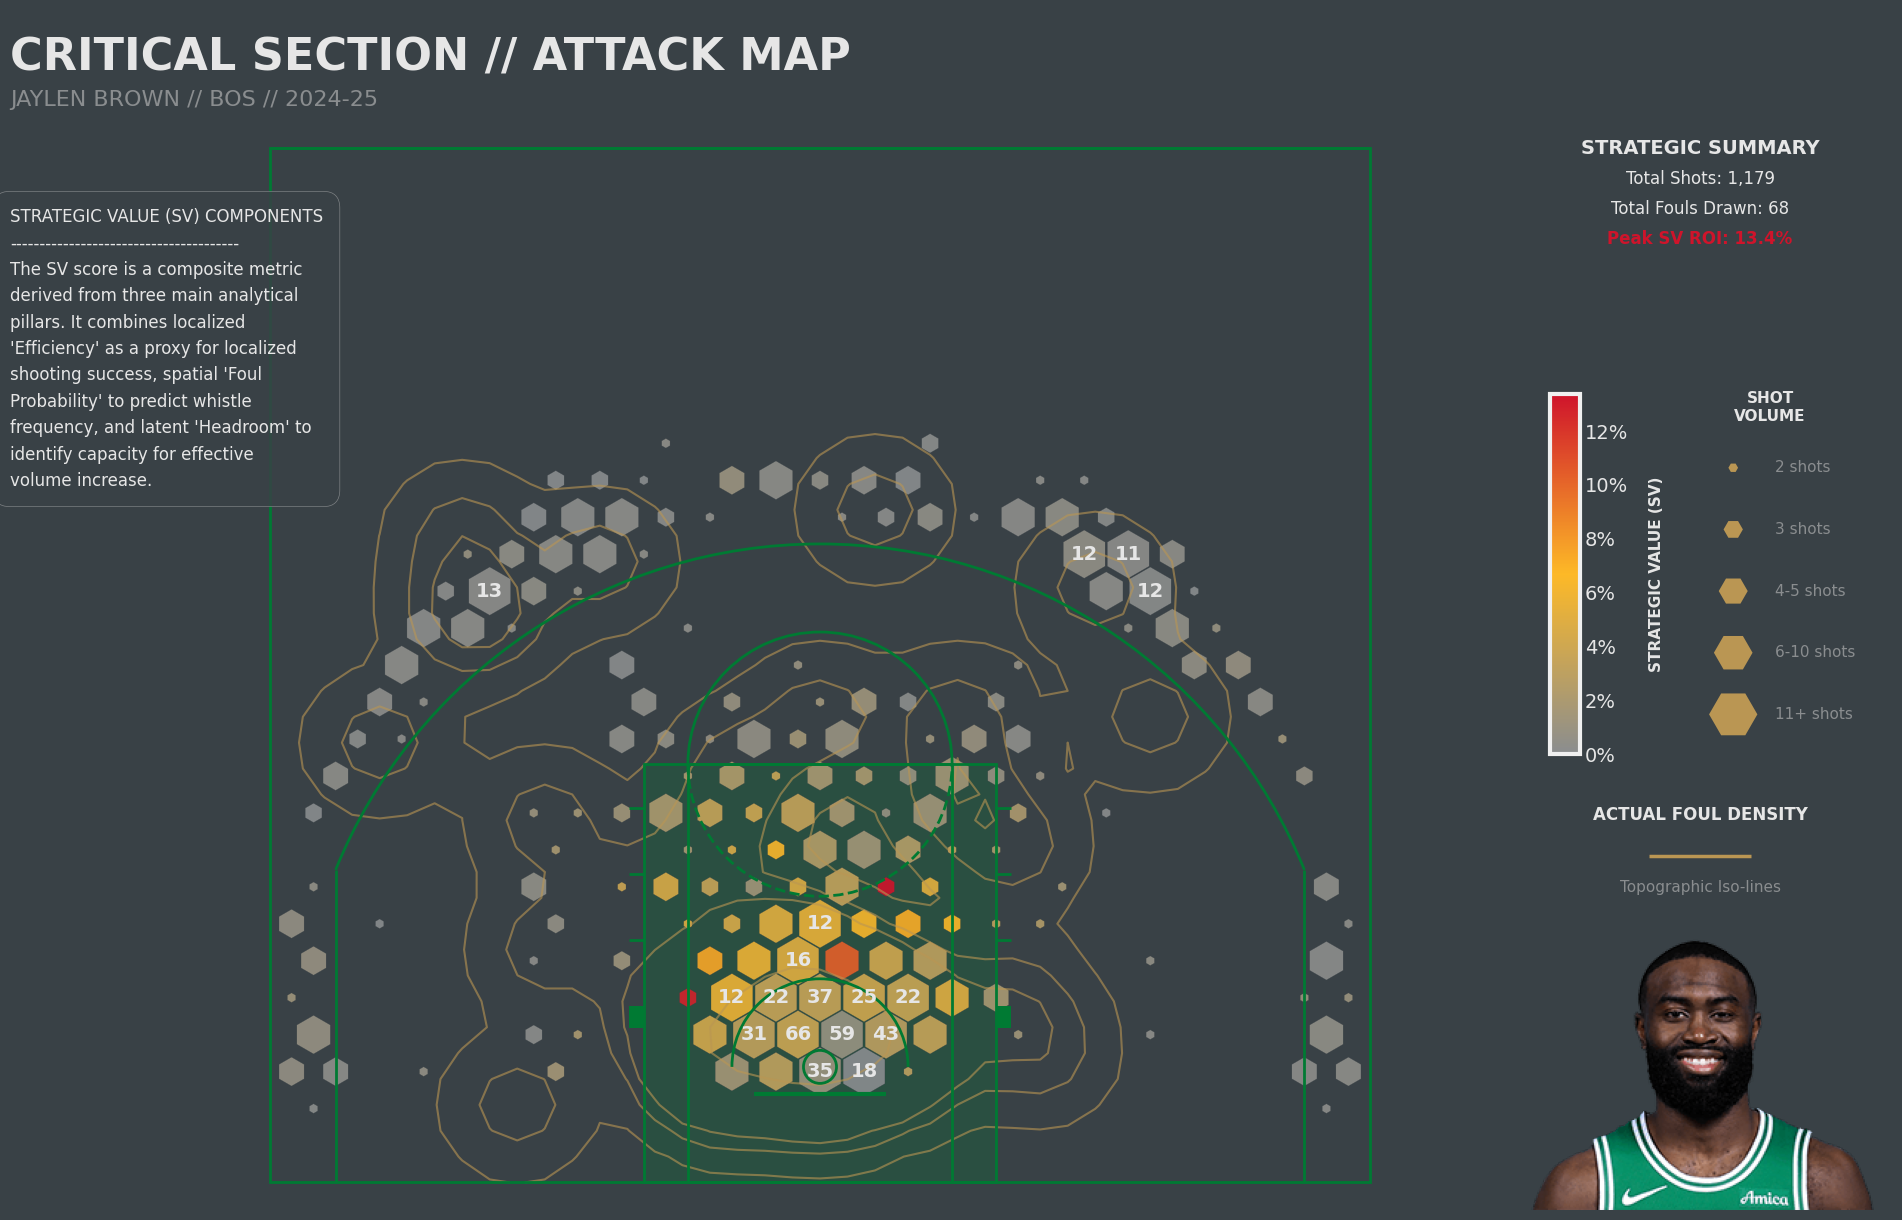

In [ ]:
# --- EXECUTE: JAYLEN BROWN (2024) ---
ind_optimization_scout(
    player_id="1627759",
    year=2024,
    df_filtered=df_filtered,
    df_analysis=df_analysis,
    foul_model=foul_model
)

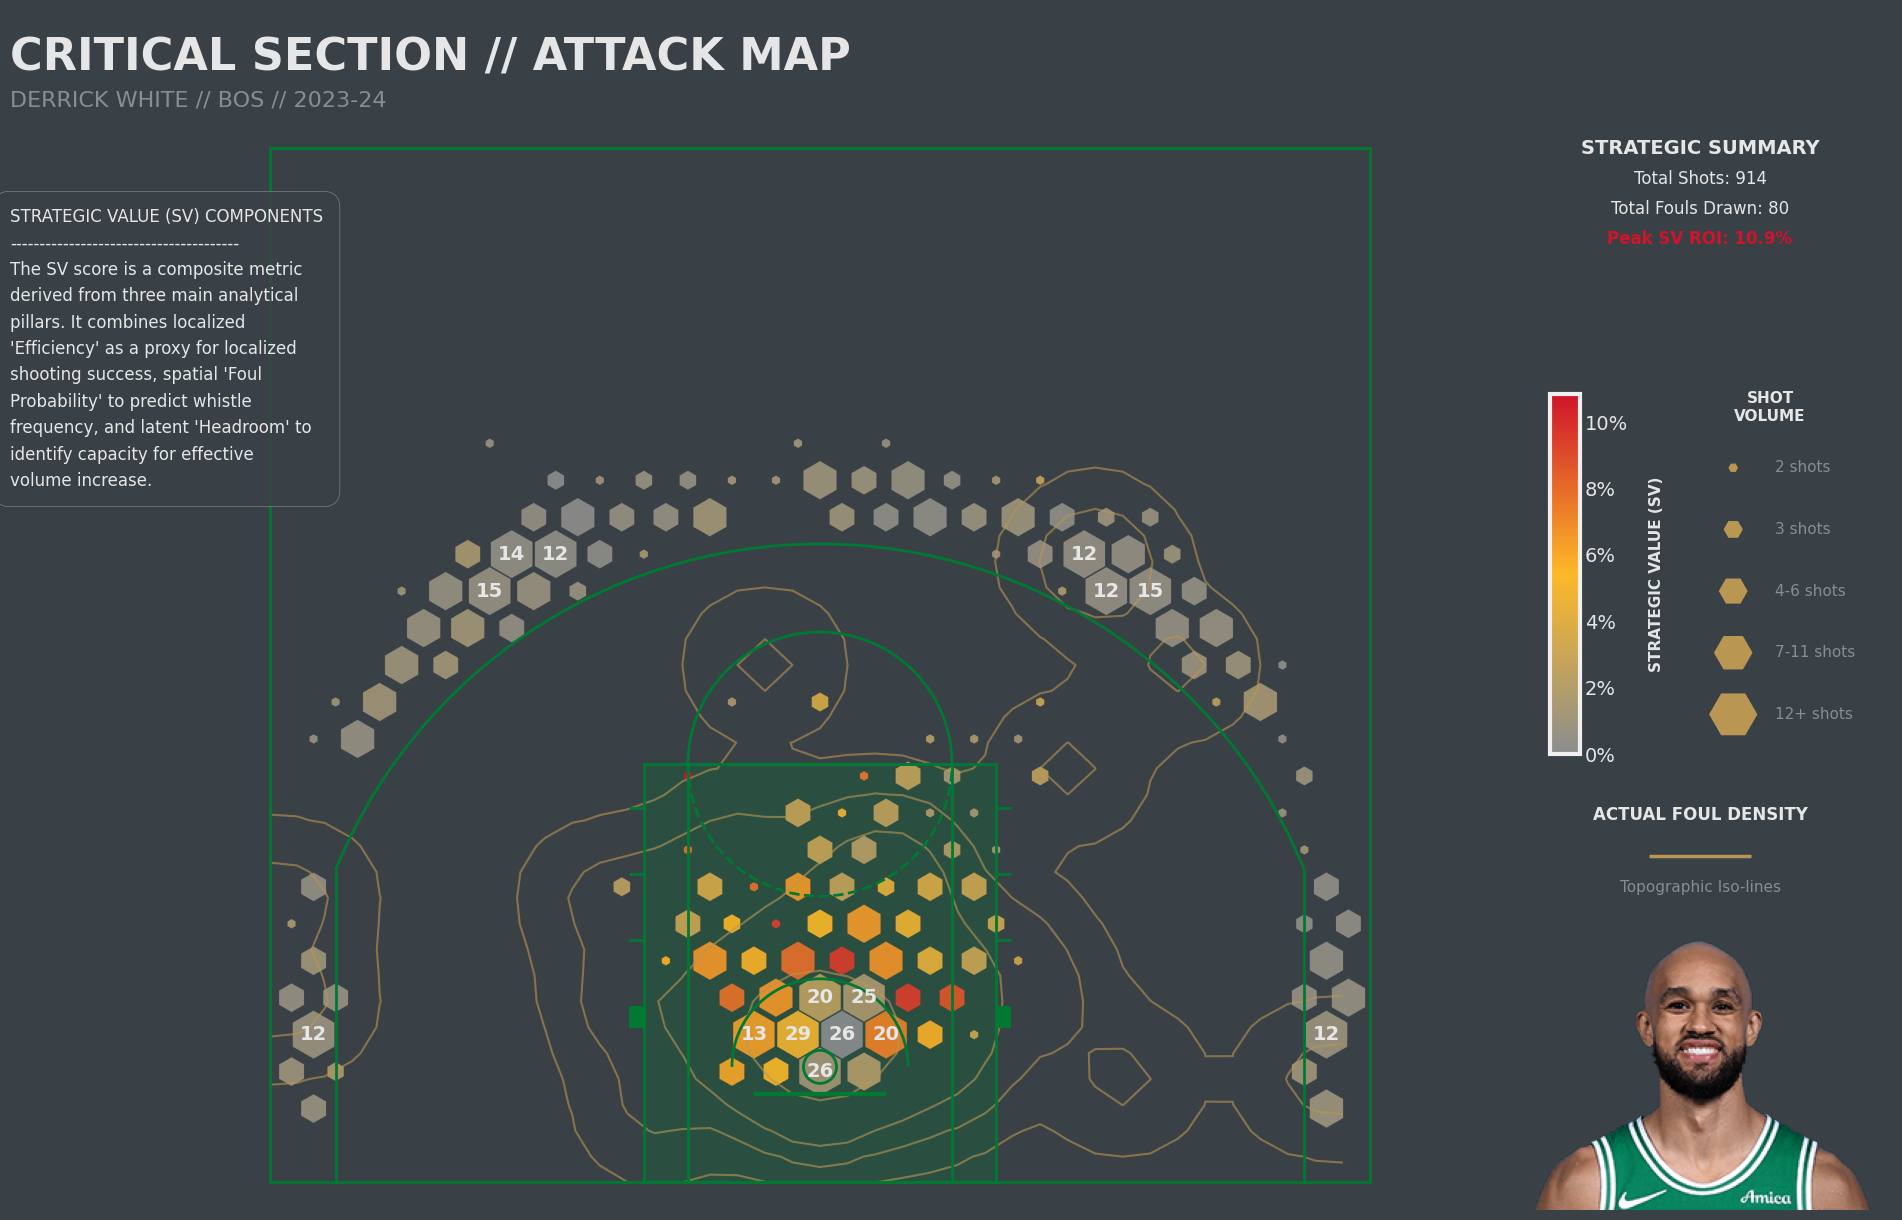

In [ ]:
# --- EXECUTE: DERRICK WHITE (2024) ---
ind_optimization_scout(
    player_id="1628401",
    year=2023,
    df_filtered=df_filtered,
    df_analysis=df_analysis,
    foul_model=foul_model
)

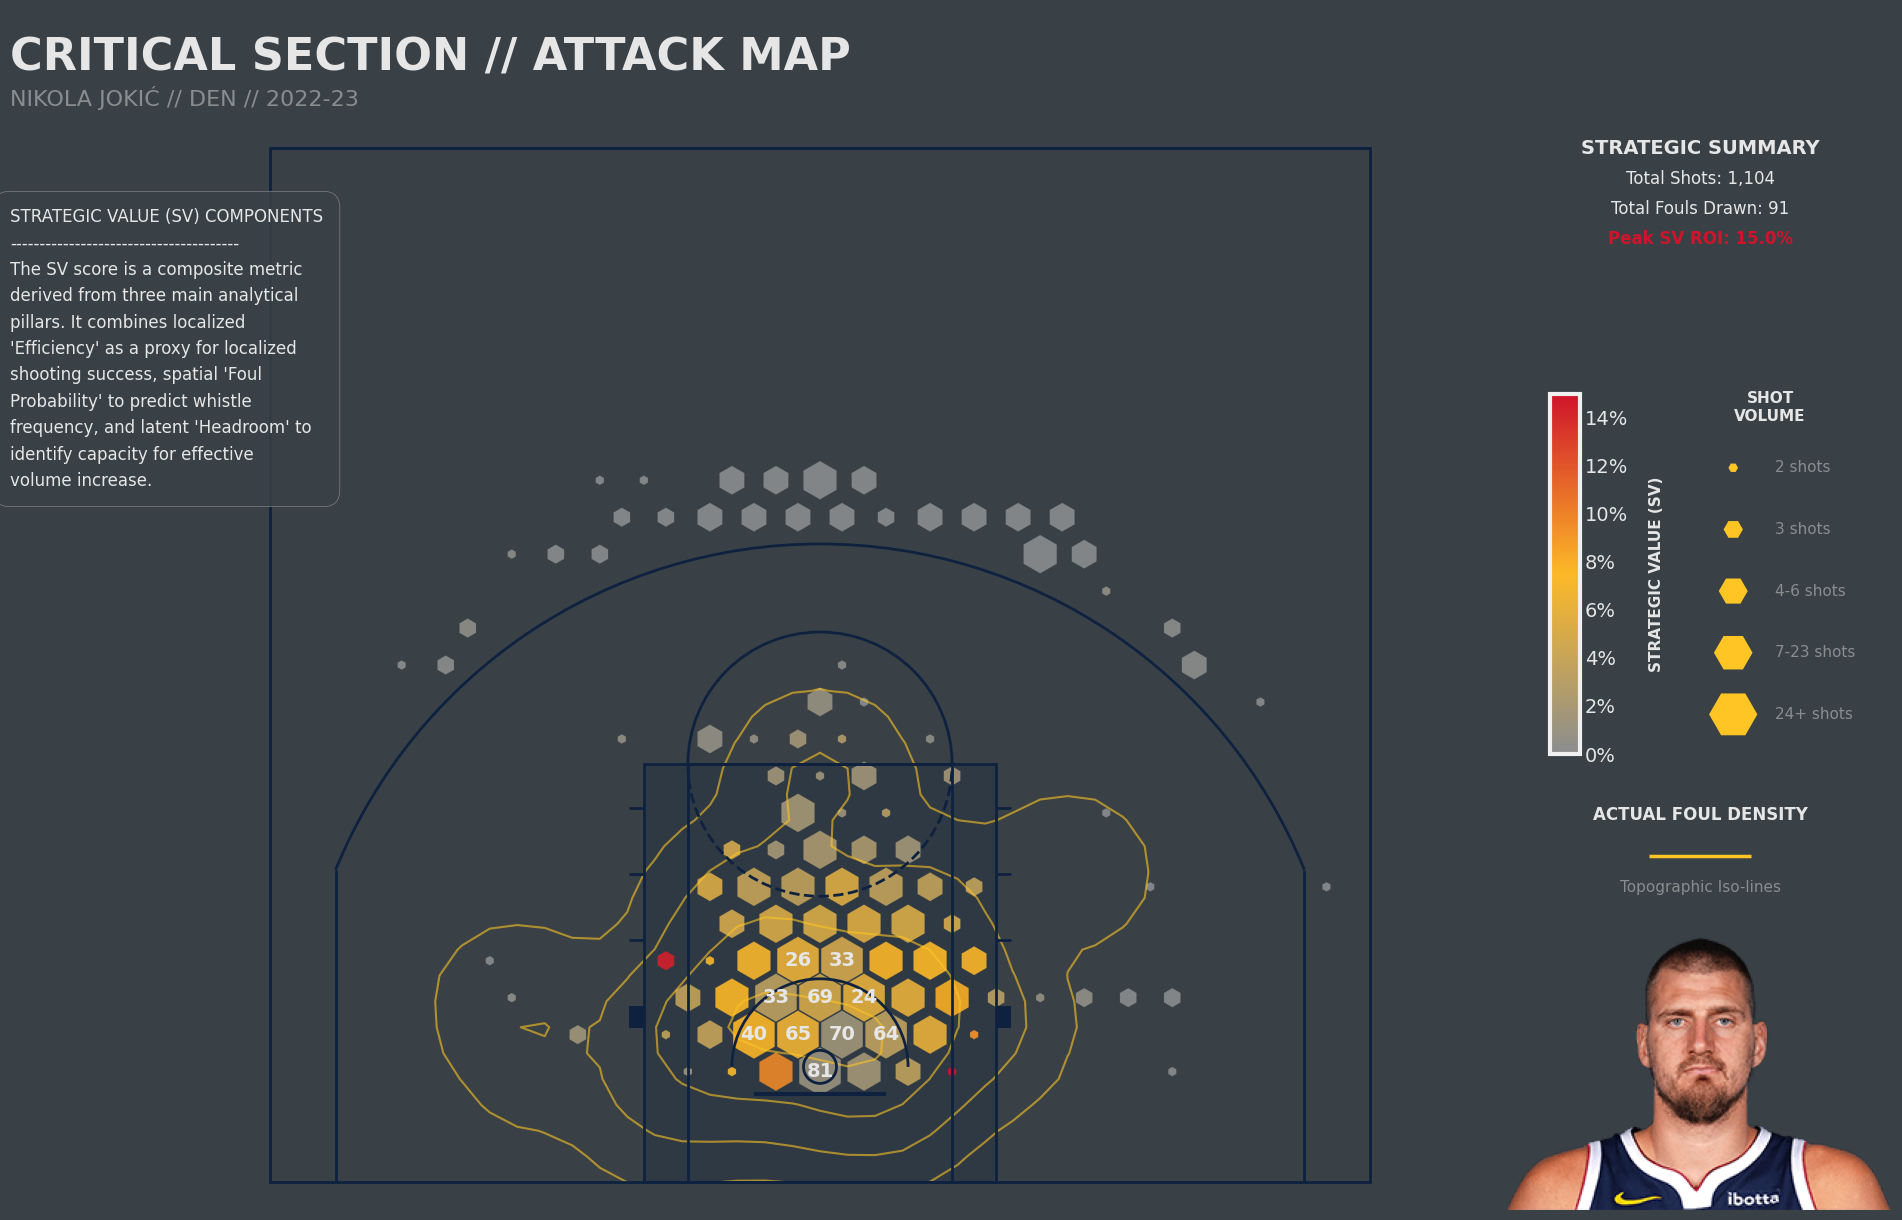

In [ ]:
# --- EXECUTE: NIKOLA JOKIC (2024) ---
ind_optimization_scout(
    player_id="203999",
    year=2022,
    df_filtered=df_filtered,
    df_analysis=df_analysis,
    foul_model=foul_model
)

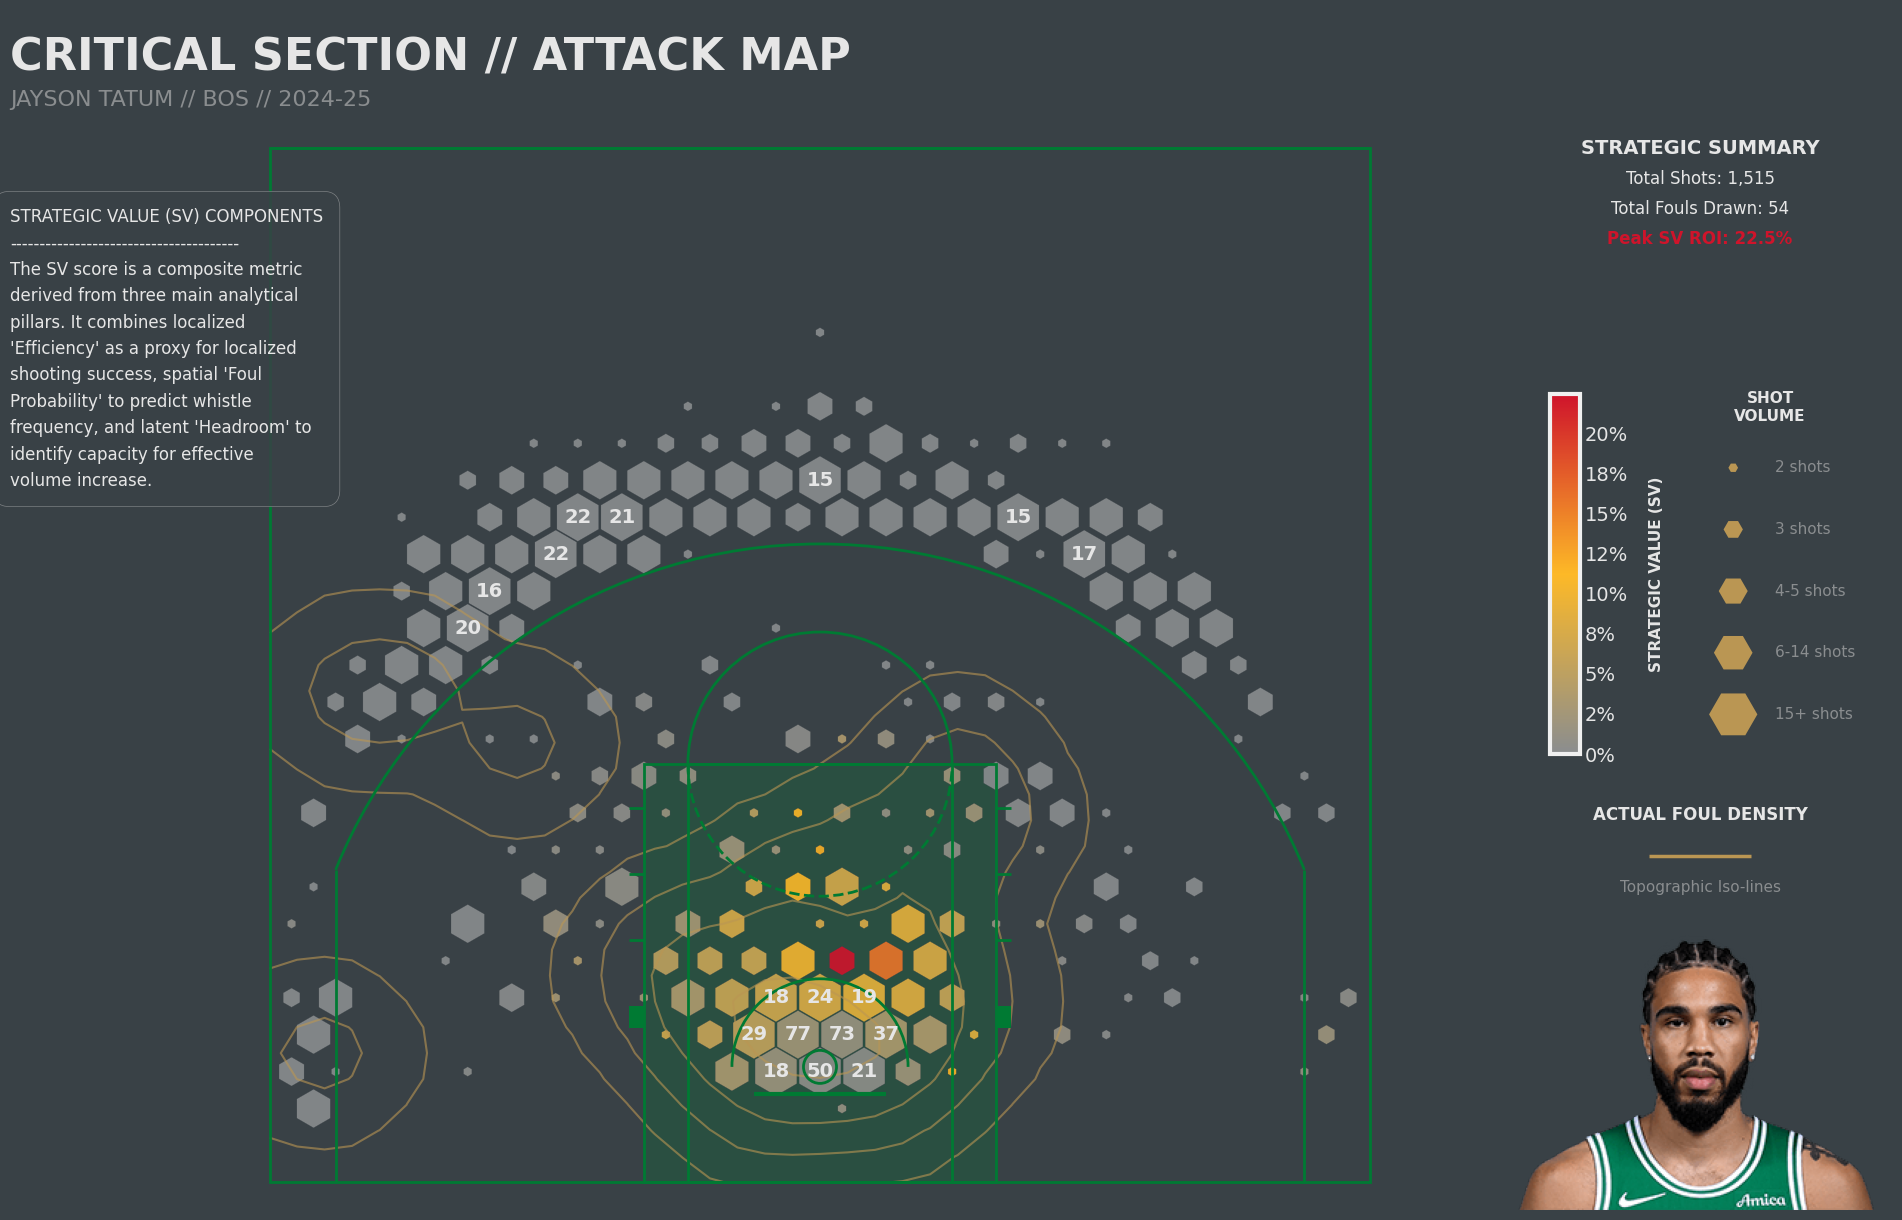

In [ ]:
# --- EXECUTE: JAYSON TATUM (2024) ---
ind_optimization_scout(
    player_id="1628369",
    year=2024,
    df_filtered=df_filtered,
    df_analysis=df_analysis,
    foul_model=foul_model
)